In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import os

# Check if cuda exist in the environment
device = "cuda" if torch.cuda.is_available() else "cpu"

print("device:", device)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

device: cuda
True
Tesla T4


In [2]:
torch.manual_seed(0); np.random.seed(0)

df = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/OptionsData/processed/surface_all.parquet")     # the full panel from 01_data_prep
DRIVE="/content/drive/MyDrive/Colab Notebooks/OptionsData/"
TICKER = "SPX"
df = df[df["ticker"] == TICKER].copy().reset_index(drop=True)
print(f"{TICKER}: {len(df)} quotes over {df['quote_date'].nunique()} days")

HOLDOUT_FRAC, MIN_VISIBLE, SPLIT_SEED = 0.20, 6, 0


def make_holdout(frame, frac, min_vis, seed):
    rng = np.random.default_rng(seed)
    hold = pd.Series(False, index=frame.index)
    for _, sl in frame.groupby(["ticker", "quote_date", "expire_date"]):
        n = len(sl)
        n_hold = min(int(round(frac * n)), max(0, n - min_vis))
        if n_hold > 0:
            hold.loc[rng.choice(sl.index.values, size=n_hold, replace=False)] = True
    return hold

df["is_holdout"] = make_holdout(df, HOLDOUT_FRAC, MIN_VISIBLE, SPLIT_SEED)

lvl = (df[~df["is_holdout"]].groupby(["ticker", "quote_date"])["iv"].median()
       .rename("day_level").reset_index())
df = df.merge(lvl, on=["ticker", "quote_date"], how="left")
df["day_level"] = df["day_level"].fillna(df["iv"].median())

n_vis, n_hold = (~df["is_holdout"]).sum(), df["is_holdout"].sum()
print(f"visible {n_vis}  held-out {n_hold}  ({100*n_hold/len(df):.1f}%)")


SPX: 1462299 quotes over 249 days
visible 1169769  held-out 292530  (20.0%)


In [3]:
def rmse(s): # RMSE scoring on held out quotes
    a = np.asarray(s, float)
    return np.nan if a.size == 0 else float(np.sqrt((a ** 2).mean()))

In [4]:
def report(frame, pred_col, name):
    d = frame[frame["is_holdout"] & frame[pred_col].notna()].copy()
    d["e"] = d["iv"] - d[pred_col]
    print(f"\n=== {name} ===  (held-out quotes scored: {len(d)})")
    print(f"overall RMSE: {rmse(d['e']):.5f}  ({rmse(d['e'])*100:.3f} vol pts)")
    mb = pd.cut(d["log_moneyness"], [-np.inf,-.10,-.03,.03,.10,np.inf],
                labels=["deep put","put","ATM","call","deep call"])
    print("by moneyness:", {k: round(v,5) for k,v in d.groupby(mb, observed=True)["e"].apply(rmse).items()})
    tb = pd.cut(d["dte"], [0,30,60,120,np.inf], labels=["<1m","1-2m","2-4m",">4m"])
    print("by maturity :", {k: round(v,5) for k,v in d.groupby(tb, observed=True)["e"].apply(rmse).items()})
    return rmse(d["e"])

results = {}
vis = df[~df["is_holdout"]]      # the data every method may train on

In [6]:
import os
FEATURES = ["log_moneyness", "tau", "day_level"]

Xtr = vis[FEATURES].values.astype("float32"); ytr = vis[["iv"]].values.astype("float32")
Xho = df.loc[df["is_holdout"], FEATURES].values.astype("float32")
X_mean, X_std = Xtr.mean(0), Xtr.std(0)
std = lambda X: (X - X_mean) / X_std

Xtr_t = torch.tensor(std(Xtr), device=device); ytr_t = torch.tensor(ytr, device=device)
Xho_t = torch.tensor(std(Xho), device=device)

#class VanillaNet(nn.Module):
#    def __init__(self, n_in=3, w=64):
#        super().__init__()
#        self.net = nn.Sequential(nn.Linear(n_in,w), nn.Softplus(),
#                                 nn.Linear(w,w), nn.Softplus(),
#                                 nn.Linear(w,w), nn.Softplus(),
#                                 nn.Linear(w,1))
#    def forward(self, x): return self.net(x)





#vanilla = VanillaNet().to(device)

#ckpt1 = f"{DRIVE}/vanilla_{TICKER}.pt"
#if os.path.exists(ckpt1):
#    vanilla.load_state_dict(torch.load(ckpt1, map_location=device))
#    print("loaded cached vanilla NN")
#else:
#    opt = torch.optim.Adam(vanilla.parameters(), lr=1e-3); lossfn = nn.MSELoss()
#    for ep in range(4000):                                   # <-- training loop
#        opt.zero_grad(); lossfn(vanilla(Xtr_t), ytr_t).backward(); opt.step()
#        if (ep+1) % 1000 == 0:
#            print(f"vanilla epoch {ep+1}: MSE {lossfn(vanilla(Xtr_t), ytr_t).item():.3e}")
#    torch.save(vanilla.state_dict(), ckpt1)
#    print("trained and cached vanilla NN")

#with torch.no_grad():
#    df.loc[df["is_holdout"], "iv_vanilla"] = vanilla(Xho_t).cpu().numpy().ravel()
#results["Vanilla NN"] = report(df, "iv_vanilla", "Vanilla NN")

In [7]:
# ===== METHOD 1: Vanilla NN — now calibrated on TOTAL VARIANCE ================
FEATURES = ["log_moneyness", "tau", "day_level"]
Xtr = vis[FEATURES].values.astype("float32")
Xho = df.loc[df["is_holdout"], FEATURES].values.astype("float32")

# target is now total variance w = iv^2 * tau, NOT iv
wtr = ((vis["iv"].values**2) * vis["tau"].values).astype("float32").reshape(-1,1)

X_mean, X_std = Xtr.mean(0), Xtr.std(0)
std = lambda X: (X - X_mean) / X_std
Xtr_t = torch.tensor(std(Xtr), device=device); wtr_t = torch.tensor(wtr, device=device)
Xho_t = torch.tensor(std(Xho), device=device)

class VanillaNet(nn.Module):
    def __init__(self, n_in=3, w=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in,w), nn.Softplus(),
                                 nn.Linear(w,w), nn.Softplus(),
                                 nn.Linear(w,w), nn.Softplus(),
                                 nn.Linear(w,1), nn.Softplus())   # Softplus => w > 0
    def forward(self, x): return self.net(x)

vanilla = VanillaNet().to(device)
opt = torch.optim.Adam(vanilla.parameters(), lr=1e-3); lossfn = nn.MSELoss()
for ep in range(4000):
    opt.zero_grad(); lossfn(vanilla(Xtr_t), wtr_t).backward(); opt.step()   # loss on w
    if (ep+1) % 1000 == 0:
        print(f"vanilla epoch {ep+1}: total-var MSE {lossfn(vanilla(Xtr_t), wtr_t).item():.3e}")

# predict w on held-out, convert back to implied vol for reporting/comparison
tau_ho = df.loc[df["is_holdout"], "tau"].values
with torch.no_grad():
    w_pred = vanilla(Xho_t).cpu().numpy().ravel()
df.loc[df["is_holdout"], "iv_vanilla"] = np.sqrt(np.clip(w_pred, 1e-12, None) / tau_ho)
results["Vanilla NN"] = report(df, "iv_vanilla", "Vanilla NN")


vanilla epoch 1000: total-var MSE 4.362e-05
vanilla epoch 2000: total-var MSE 8.935e-06
vanilla epoch 3000: total-var MSE 5.967e-06
vanilla epoch 4000: total-var MSE 4.863e-06

=== Vanilla NN ===  (held-out quotes scored: 292530)
overall RMSE: 0.04706  (4.706 vol pts)
by moneyness: {'deep put': 0.03141, 'put': 0.05632, 'ATM': 0.05772, 'call': 0.03265, 'deep call': 0.05627}
by maturity : {'<1m': 0.07086, '1-2m': 0.0238, '2-4m': 0.02341, '>4m': 0.02197}


In [8]:
# SVI
def svi_raw(k, a, b, rho, m, sigma):
    return a + b * (rho*(k - m) + np.sqrt((k - m)**2 + sigma**2))

def fit_slice(k, w):
    k = np.asarray(k,float); w = np.asarray(w,float)
    if len(k) < 6: return None
    p0 = [max(w.min(),1e-6), 0.1, -0.3, 0.0, 0.1]
    lb = [0.0, 0.0, -0.999, k.min()-0.5, 1e-4]
    ub = [w.max()*5+1e-6, 10.0, 0.999, k.max()+0.5, 2.0]
    p0 = [min(max(p0[i],lb[i]),ub[i]) for i in range(5)]
    try:
        return least_squares(lambda p: svi_raw(k,*p)-w, p0, bounds=(lb,ub), max_nfev=10000).x
    except Exception:
        return None

def fit_svi_construction(frame):
    out = pd.Series(np.nan, index=frame.index, dtype=float)
    for _, sl in frame.groupby(["ticker","quote_date","expire_date"]):
        v = sl[~sl["is_holdout"]]; h = sl[sl["is_holdout"]]
        if len(v) < 6 or len(h) == 0: continue
        tau = sl["tau"].iloc[0]
        p = fit_slice(v["log_moneyness"].values, (v["iv"].values**2)*tau)
        if p is None: continue
        out.loc[h.index] = np.sqrt(np.clip(svi_raw(h["log_moneyness"].values,*p),1e-12,None)/tau)
    return out

# --- SVI cache: store the held-out predictions, not weights (SVI has none) ---
svi_cache = f"{DRIVE}/svi_pred_{TICKER}.parquet"
if os.path.exists(svi_cache):
    cached = pd.read_parquet(svi_cache)
    df["iv_svi"] = cached["iv_svi"].values
    print("loaded cached SVI predictions")
else:
    df["iv_svi"] = fit_svi_construction(df)
    df[["iv_svi"]].to_parquet(svi_cache)
    print("fit and cached SVI predictions")

results["SVI"] = report(df, "iv_svi", "SVI")

loaded cached SVI predictions

=== SVI ===  (held-out quotes scored: 292530)
overall RMSE: 0.00889  (0.889 vol pts)
by moneyness: {'deep put': 0.00454, 'put': 0.00552, 'ATM': 0.00851, 'call': 0.01224, 'deep call': 0.0188}
by maturity : {'<1m': 0.01099, '1-2m': 0.01014, '2-4m': 0.00777, '>4m': 0.00413}


In [9]:
#Method 3 Deep NN
prior_slices = {}
for tau_val, g in vis.groupby(vis["tau"].round(6)):
    g = g.copy(); g["kbin"] = g["log_moneyness"].round(3)
    med = g.groupby("kbin").agg(k=("log_moneyness","mean"), w=("total_var","median")).sort_values("k")
    if len(med) < 6: continue
    p = fit_slice(med["k"].values, med["w"].values)
    if p is not None: prior_slices[float(tau_val)] = p
prior_taus = np.array(sorted(prior_slices)); prior_par = np.array([prior_slices[t] for t in prior_taus])

def prior_w(k, tau):
    k = np.asarray(k,float); tau = np.asarray(tau,float)
    a   = np.interp(tau, prior_taus, prior_par[:,0]); b   = np.interp(tau, prior_taus, prior_par[:,1])
    rho = np.interp(tau, prior_taus, prior_par[:,2]); m   = np.interp(tau, prior_taus, prior_par[:,3])
    sig = np.interp(tau, prior_taus, prior_par[:,4])
    return np.maximum(a + b*(rho*(k-m) + np.sqrt((k-m)**2 + sig**2)), 1e-8)

K_MEAN, K_STD = float(vis["log_moneyness"].mean()), float(vis["log_moneyness"].std())
T_MEAN, T_STD = float(vis["tau"].mean()),           float(vis["tau"].std())
L_MEAN, L_STD = float(vis["day_level"].mean()),     float(vis["day_level"].std())

class DeepSmoothing(nn.Module):
    """w(k,tau) = w_prior(k,tau) * softplus(nn(k,tau,level)). The level input is
    constant per point, so it does not affect the d/dk, d/dtau arbitrage terms."""
    def __init__(self, w=40, depth=4):
        super().__init__()
        layers = [nn.Linear(3, w), nn.Softplus()]
        for _ in range(depth - 1):
            layers += [nn.Linear(w, w), nn.Softplus()]
        layers += [nn.Linear(w, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, k, tau, wprior, level):
        x = torch.stack([(k - K_MEAN)/K_STD, (tau - T_MEAN)/T_STD, (level - L_MEAN)/L_STD], dim=1)
        return wprior * torch.nn.functional.softplus(self.net(x)).squeeze(-1)


In [10]:
# trained with no arbitrage penalty
def T(col, frame=vis, grad=False):
    return torch.tensor(frame[col].values, dtype=torch.float32, requires_grad=grad, device=device)

k_tr = T("log_moneyness", vis, grad=True); t_tr = T("tau", vis, grad=True)
l_tr = T("day_level", vis); wp_tr = torch.tensor(prior_w(vis["log_moneyness"].values, vis["tau"].values),
                                                 dtype=torch.float32, device=device)
w_obs = torch.tensor((vis["iv"].values**2)*vis["tau"].values, dtype=torch.float32, device=device)

def roper_penalties(model, k, tau, wprior, level):
    w = model(k, tau, wprior, level)
    dwdk,   = torch.autograd.grad(w, k, torch.ones_like(w), create_graph=True)
    d2wdk2, = torch.autograd.grad(dwdk, k, torch.ones_like(dwdk), create_graph=True)
    dwdt,   = torch.autograd.grad(w, tau, torch.ones_like(w), create_graph=True)
    cal = torch.relu(-dwdt)
    g = (1 - k*dwdk/(2*w))**2 - (dwdk/4)*(1/w + 0.25) + d2wdk2/2
    return w, cal.mean(), torch.relu(-g).mean(), d2wdk2.pow(2).mean()

model3 = DeepSmoothing().to(device)
LAMBDA_CAL, LAMBDA_BUT, LAMBDA_SMOOTH = 1.0, 1.0, 1e-4

ckpt3 = f"{DRIVE}/deep_{TICKER}.pt"
if os.path.exists(ckpt3):
    model3.load_state_dict(torch.load(ckpt3, map_location=device))
    print("loaded cached deep-smoothing NN")
else:
    opt = torch.optim.Adam(model3.parameters(), lr=1e-3)
    for ep in range(4000):                                   # <-- training loop
        opt.zero_grad()
        w_pred, cal, but, smooth = roper_penalties(model3, k_tr, t_tr, wp_tr, l_tr)
        loss = ((w_pred - w_obs)**2).mean() + LAMBDA_CAL*cal + LAMBDA_BUT*but + LAMBDA_SMOOTH*smooth
        loss.backward(); opt.step()
        if (ep+1) % 1000 == 0:
            print(f"deep epoch {ep+1}: cal {cal.item():.2e}  but {but.item():.2e}")
    torch.save(model3.state_dict(), ckpt3)
    print("trained and cached deep-smoothing NN")

hd = df[df["is_holdout"]]
k_ho = torch.tensor(hd["log_moneyness"].values, dtype=torch.float32, device=device)
t_ho = torch.tensor(hd["tau"].values, dtype=torch.float32, device=device)
l_ho = torch.tensor(hd["day_level"].values, dtype=torch.float32, device=device)
wp_ho = torch.tensor(prior_w(hd["log_moneyness"].values, hd["tau"].values), dtype=torch.float32, device=device)
with torch.no_grad():
    w_ho = model3(k_ho, t_ho, wp_ho, l_ho)
df.loc[df["is_holdout"], "iv_deep"] = np.sqrt(np.clip(w_ho.cpu().numpy(), 1e-12, None) / hd["tau"].values)
results["Deep Smoothing"] = report(df, "iv_deep", "Deep Smoothing")



loaded cached deep-smoothing NN

=== Deep Smoothing ===  (held-out quotes scored: 292530)
overall RMSE: 0.02370  (2.370 vol pts)
by moneyness: {'deep put': 0.01653, 'put': 0.02246, 'ATM': 0.0321, 'call': 0.02567, 'deep call': 0.0152}
by maturity : {'<1m': 0.03303, '1-2m': 0.02046, '2-4m': 0.01605, '>4m': 0.01086}


In [11]:
# Arbitrage violtation count
# evaluated at a representative day level (median across days)
LEVEL0 = float(df["day_level"].median())

def count_violations_grid(predict_w, k_pts, t_pts, eps_k=1e-3, eps_t=1e-3):
    k = np.asarray(k_pts,float); t = np.asarray(t_pts,float)
    w   = predict_w(k, t)
    wk  = (predict_w(k+eps_k, t) - predict_w(k-eps_k, t)) / (2*eps_k)
    wkk = (predict_w(k+eps_k, t) - 2*w + predict_w(k-eps_k, t)) / eps_k**2
    wt  = (predict_w(k, t+eps_t) - predict_w(k, t-eps_t)) / (2*eps_t)
    g = (1 - k*wk/(2*w))**2 - (wk/4)*(1/w + 0.25) + wkk/2
    return int((g < 0).sum()), int((wt < 0).sum())

kg = np.linspace(df["log_moneyness"].min(), df["log_moneyness"].max(), 60)
tg = np.linspace(df["tau"].min(), df["tau"].max(), 30)
KK, TT = np.meshgrid(kg, tg); KKr, TTr = KK.ravel(), TT.ravel()

def deep_w(k, t):
    kt = torch.tensor(k, dtype=torch.float32, device=device)
    tt = torch.tensor(t, dtype=torch.float32, device=device)
    lt = torch.full_like(kt, LEVEL0)
    wp = torch.tensor(prior_w(k, t), dtype=torch.float32, device=device)
    with torch.no_grad():
        return model3(kt, tt, wp, lt).cpu().numpy()

def vanilla_w(k, t):
    L = np.full_like(np.asarray(k,float), LEVEL0)
    X = std(np.column_stack([k, t, L]).astype("float32"))
    with torch.no_grad():
        iv = vanilla(torch.tensor(X, device=device)).cpu().numpy().ravel()
    return iv**2 * np.asarray(t, float)

vb, vc = count_violations_grid(vanilla_w, KKr, TTr)
db, dc = count_violations_grid(deep_w, KKr, TTr)
print(f"\nArbitrage violations on a {len(KKr)}-point grid (at median day level):")
print(f"  Vanilla NN     : butterfly {vb:5d}   calendar {vc:5d}")
print(f"  Deep Smoothing : butterfly {db:5d}   calendar {dc:5d}")



Arbitrage violations on a 1800-point grid (at median day level):
  Vanilla NN     : butterfly     0   calendar     0
  Deep Smoothing : butterfly   145   calendar   725


In [14]:
'''import pickle, os, numpy as np, pandas as pd
os.makedirs(DRIVE, exist_ok=True)

plot_data = {
    "ticker": TICKER,

    # per-quote predictions (held-out set carries the columns the plots use)
    "hold": df[df["is_holdout"]][
        ["ticker","quote_date","expire_date","dte","tau","log_moneyness","iv",
         "iv_vanilla","iv_svi","iv_deep"]
    ].reset_index(drop=True),

    # scalar results table
    "results": dict(results),                      # {method: holdout_rmse}

    # arbitrage counts, if you computed them  (else set to {})
    "arb": arb if "arb" in dir() else {},

    # hedging P&L arrays, if you ran the hedge  (else {})
    "pnl": {f"{n}|{m}": pnl[(n, m)] for (n, m) in pnl} if "pnl" in dir() else {},
    "money": MONEY if "MONEY" in dir() else [],
    "hedge_stats": hedge_stats if "hedge_stats" in dir() else {},

    # a precomputed g(k) / calendar grid for the arbitrage plots, if you have them
    # (add any other arrays your plots need here)
}

with open(f"{DRIVE}/plot_data_{TICKER}.pkl", "wb") as f:
    pickle.dump(plot_data, f)

print(f"saved {DRIVE}/plot_data_{TICKER}.pkl")
print("contents:", {k: (type(v).__name__) for k, v in plot_data.items()})
'''
svi_surf = {}
for tv, g in df.groupby(df["tau"].round(6)):
    p = fit_slice(g["log_moneyness"].values, (g["iv"].values**2)*float(tv))
    if p is not None:
        svi_surf[float(tv)] = p
svi_taus = np.array(sorted(svi_surf)); svi_pars = np.array([svi_surf[t] for t in svi_taus])

def svi_surface_w(k, t):
    k = np.asarray(k, float); t = np.asarray(t, float)
    a   = np.interp(t, svi_taus, svi_pars[:,0]); b   = np.interp(t, svi_taus, svi_pars[:,1])
    rho = np.interp(t, svi_taus, svi_pars[:,2]); m   = np.interp(t, svi_taus, svi_pars[:,3])
    sig = np.interp(t, svi_taus, svi_pars[:,4])
    return np.maximum(a + b*(rho*(k-m) + np.sqrt((k-m)**2 + sig**2)), 1e-8)

# ---- PRECOMPUTE arbitrage curves so ANY file can plot them -------------------
import numpy as np, pickle

# a representative day's slice for the butterfly g(k) curve
day = df[df["is_holdout"]]["quote_date"].max()
d0  = df[df["quote_date"] == day]
exp = d0["expire_date"].value_counts().idxmax()
sl  = d0[d0["expire_date"] == exp]
tau_g = float(sl["tau"].iloc[0])
kline = np.linspace(sl["log_moneyness"].min(), sl["log_moneyness"].max(), 120)

def g_of(w_fn, k, tau, eps=1e-3):
    tv = np.full_like(k, tau, dtype=float)
    w  = w_fn(k, tv); wk = (w_fn(k+eps,tv)-w_fn(k-eps,tv))/(2*eps)
    wkk = (w_fn(k+eps,tv)-2*w+w_fn(k-eps,tv))/eps**2
    return (1 - k*wk/(2*w))**2 - (wk/4)*(1/w+0.25) + wkk/2

# calendar: total variance across maturities at fixed k
tau_fine = np.linspace(df["tau"].min(), df["tau"].max(), 60)
k_fixed  = np.linspace(df["log_moneyness"].min(), df["log_moneyness"].max(), 9)

arb_curves = {"kline": kline, "tau_g": tau_g, "day": str(day.date()),
              "tau_fine": tau_fine, "k_fixed": k_fixed, "g": {}, "cal": {}}
SURFACES = {"SVI": svi_surface_w, "Vanilla NN": vanilla_w, "Deep Smoothing": deep_w}
for name, wf in SURFACES.items():
    arb_curves["g"][name]   = g_of(wf, kline, tau_g)                       # butterfly curve
    arb_curves["cal"][name] = np.array([wf(np.full_like(tau_fine, k0), tau_fine)
                                        for k0 in k_fixed])                # calendar lines

with open(f"{DRIVE}/arb_curves_{TICKER}.pkl", "wb") as f:
    pickle.dump(arb_curves, f)
print(f"saved {DRIVE}/arb_curves_{TICKER}.pkl — arbitrage plots now reproducible from data alone")

saved /content/drive/MyDrive/Colab Notebooks/OptionsData//arb_curves_SPX.pkl — arbitrage plots now reproducible from data alone


In [15]:
# Reading the input for drawing


In [16]:
# ---- LOAD ALL PLOT DATA ------------------------------------------------------
import pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt

TICKER = "SPX"
DRIVE  = "/content/drive/MyDrive/Colab Notebooks/OptionsData"   # your folder

with open(f"{DRIVE}/plot_data_{TICKER}.pkl", "rb") as f:
    D = pickle.load(f)

# unpack into the names your plotting code expects
hold        = D["hold"]                       # DataFrame of held-out quotes + predictions
results     = D["results"]                    # {method: rmse}
arb         = D["arb"]                        # {method: {"butterfly":..,"calendar":..}}
MONEY       = D["money"]
hedge_stats = D["hedge_stats"]
# rebuild the pnl dict with tuple keys
pnl = {tuple(k.split("|", 1)[0:1]) + (float(k.split("|",1)[1]),): np.asarray(v)
       for k, v in D["pnl"].items()} if D["pnl"] else {}

print("loaded:", list(D.keys()))
print(f"{len(hold)} held-out quotes | methods: {list(results)}")

loaded: ['ticker', 'hold', 'results', 'arb', 'pnl', 'money', 'hedge_stats']
292530 held-out quotes | methods: ['Vanilla NN', 'SVI', 'Deep Smoothing']


In [17]:
#Comparison Table
print("\n========== HELD-OUT RECONSTRUCTION RMSE (Job A) ==========")
summary = pd.DataFrame({"holdout_RMSE": results}).round(5)
summary["vol_pts"] = (summary["holdout_RMSE"]*100).round(3)
print(summary.to_string())



========== HELD-OUT RECONSTRUCTION RMSE (Job A) ==========
                holdout_RMSE  vol_pts
Vanilla NN           0.01362    1.362
SVI                  0.00889    0.889
Deep Smoothing       0.02370    2.370


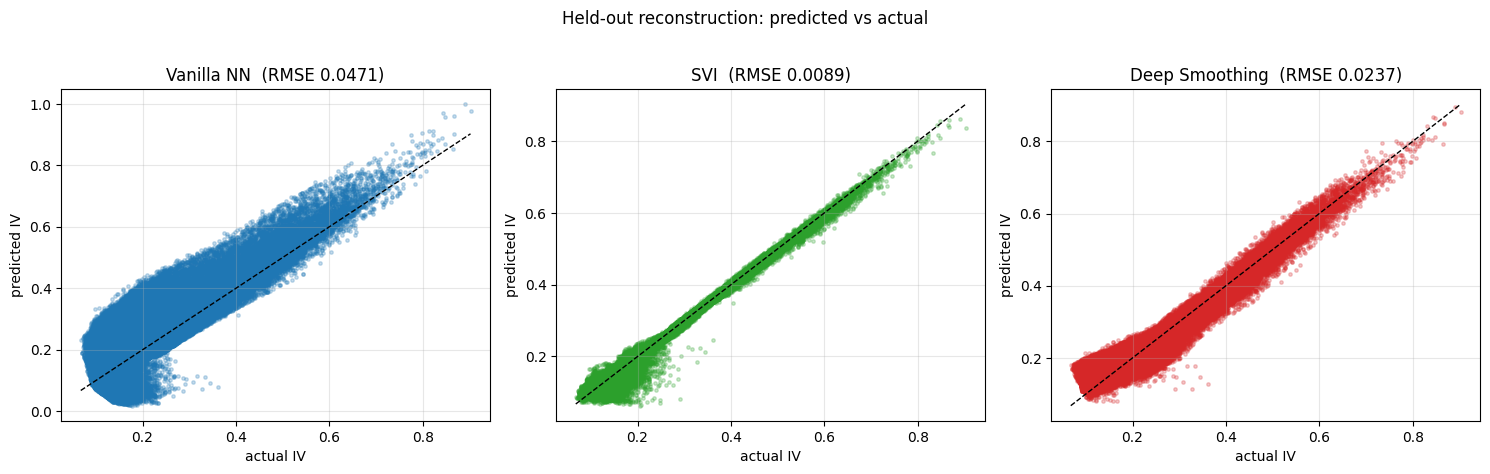

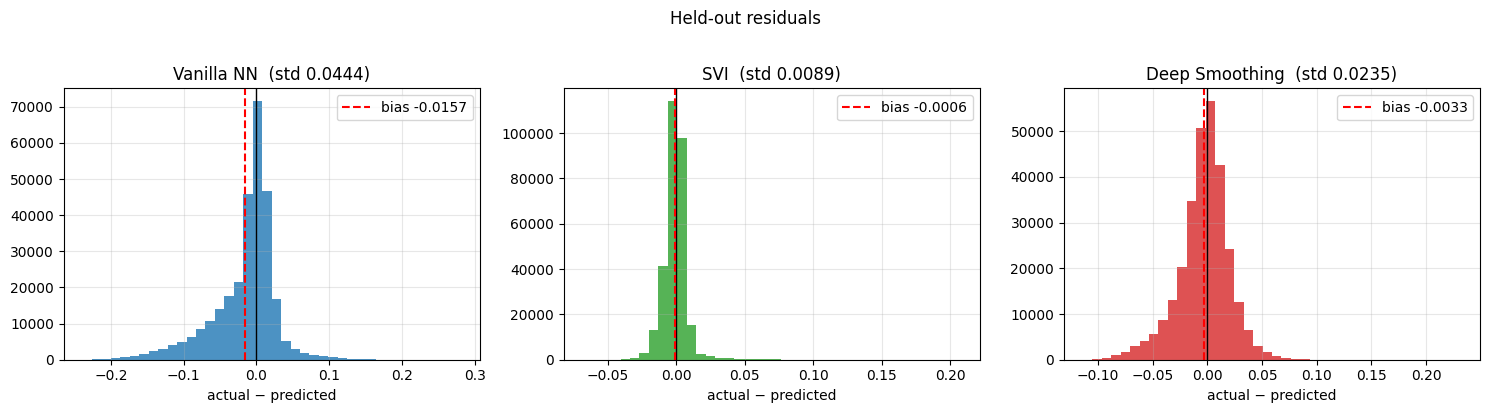

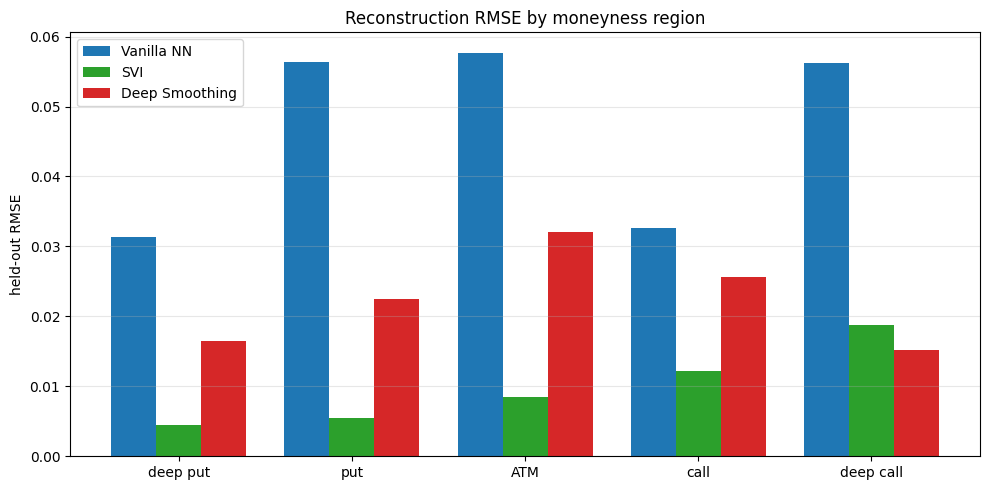

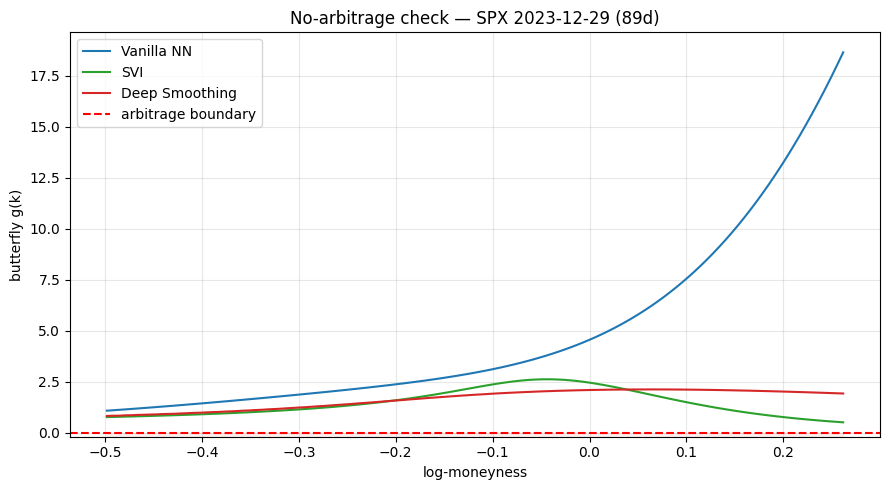

In [18]:
# Validation plots
hold = df[df["is_holdout"]].copy()
METHODS = [("Vanilla NN","iv_vanilla"), ("SVI","iv_svi"), ("Deep Smoothing","iv_deep")]
COLORS  = {"Vanilla NN":"#1f77b4", "SVI":"#2ca02c", "Deep Smoothing":"#d62728"}

# predicted vs actual
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (name, col) in zip(axes, METHODS):
    d = hold[hold[col].notna()]
    ax.scatter(d["iv"], d[col], s=6, alpha=0.25, color=COLORS[name])
    lo, hi = d["iv"].min(), d["iv"].max(); ax.plot([lo,hi],[lo,hi],"k--",lw=1)
    ax.set_title(f"{name}  (RMSE {rmse(d['iv']-d[col]):.4f})")
    ax.set_xlabel("actual IV"); ax.set_ylabel("predicted IV"); ax.grid(alpha=0.3)
fig.suptitle("Held-out reconstruction: predicted vs actual", y=1.02)
plt.tight_layout(); plt.show()

# residual distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, col) in zip(axes, METHODS):
    res = (hold["iv"] - hold[col]).dropna()
    ax.hist(res, bins=40, color=COLORS[name], alpha=0.8)
    ax.axvline(0, color="k", lw=1); ax.axvline(res.mean(), color="red", ls="--", lw=1.5,
                                               label=f"bias {res.mean():+.4f}")
    ax.set_title(f"{name}  (std {res.std():.4f})"); ax.set_xlabel("actual − predicted"); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("Held-out residuals", y=1.02); plt.tight_layout(); plt.show()

# RMSE by moneyness region
regions = ["deep put","put","ATM","call","deep call"]
hold["m_bucket"] = pd.cut(hold["log_moneyness"], [-np.inf,-.10,-.03,.03,.10,np.inf], labels=regions)
x = np.arange(len(regions)); width = 0.26
fig, ax = plt.subplots(figsize=(10,5))
for i,(name,col) in enumerate(METHODS):
    vals = [rmse((hold.loc[hold.m_bucket==r,"iv"]-hold.loc[hold.m_bucket==r,col]).dropna()) for r in regions]
    ax.bar(x+i*width, vals, width, label=name, color=COLORS[name])
ax.set_xticks(x+width); ax.set_xticklabels(regions); ax.set_ylabel("held-out RMSE")
ax.set_title("Reconstruction RMSE by moneyness region"); ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

# butterfly no arbitrage check
day = hold["quote_date"].max(); d0 = df[df["quote_date"] == day]
exp = d0["expire_date"].value_counts().idxmax(); sl = d0[d0["expire_date"] == exp]
tau_val = float(sl["tau"].iloc[0]); kline = np.linspace(sl["log_moneyness"].min(), sl["log_moneyness"].max(), 120)

def g_of(predict_w, k, tau, eps=1e-3):
    tv = np.full_like(k, tau, dtype=float)
    w = predict_w(k, tv); wk=(predict_w(k+eps,tv)-predict_w(k-eps,tv))/(2*eps)
    wkk=(predict_w(k+eps,tv)-2*w+predict_w(k-eps,tv))/eps**2
    return (1-k*wk/(2*w))**2 - (wk/4)*(1/w+0.25) + wkk/2

svi_p = fit_slice(sl["log_moneyness"].values, (sl["iv"].values**2)*tau_val)
svi_w = lambda k,t: svi_raw(k,*svi_p)
plt.figure(figsize=(9,5))
plt.plot(kline, g_of(vanilla_w, kline, tau_val), label="Vanilla NN", color=COLORS["Vanilla NN"])
plt.plot(kline, g_of(svi_w,     kline, tau_val), label="SVI", color=COLORS["SVI"])
plt.plot(kline, g_of(deep_w,    kline, tau_val), label="Deep Smoothing", color=COLORS["Deep Smoothing"])
plt.axhline(0, color="red", ls="--", lw=1.5, label="arbitrage boundary"); plt.fill_between(kline,-1,0,color="red",alpha=0.06)
plt.ylim(bottom=min(-0.2, float(g_of(deep_w, kline, tau_val).min())))
plt.xlabel("log-moneyness"); plt.ylabel("butterfly g(k)")
plt.title(f"No-arbitrage check — {TICKER} {day.date()} ({int(sl['dte'].iloc[0])}d)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


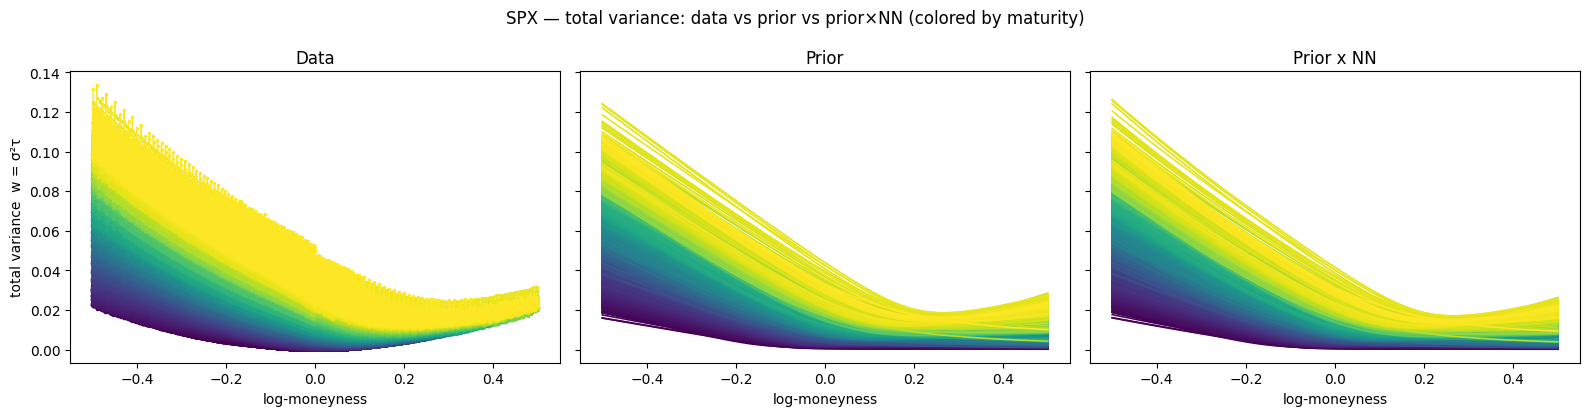

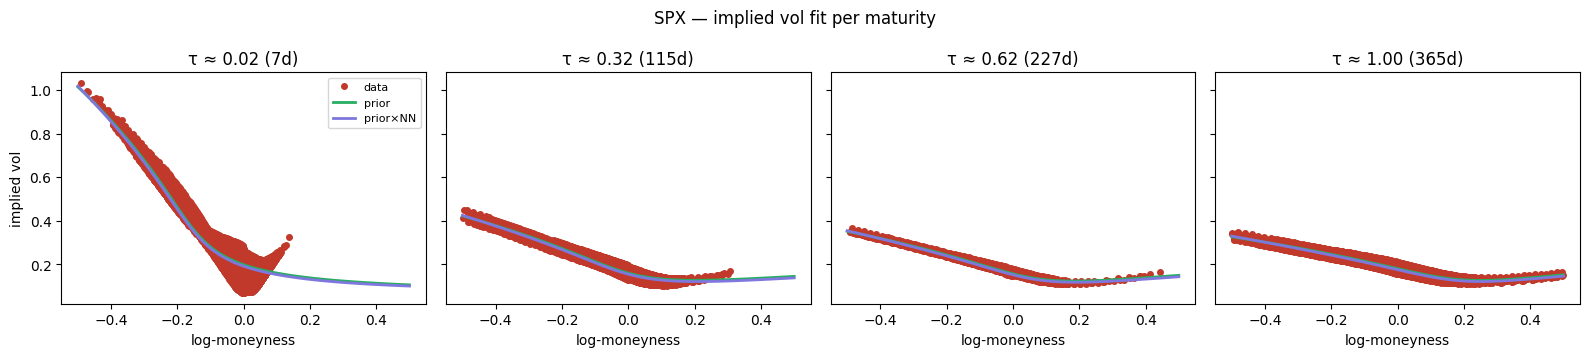

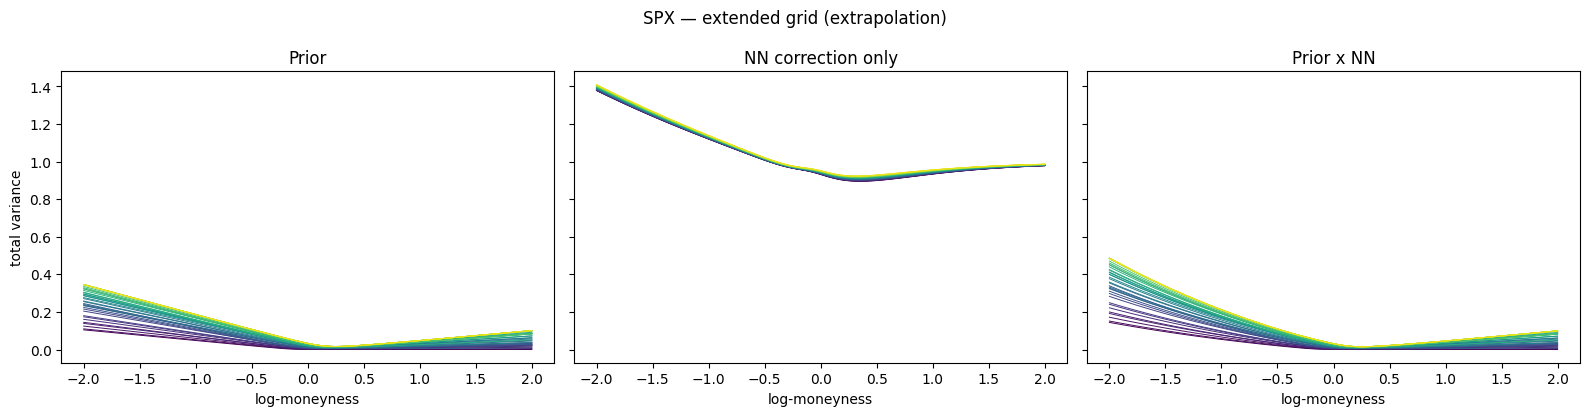

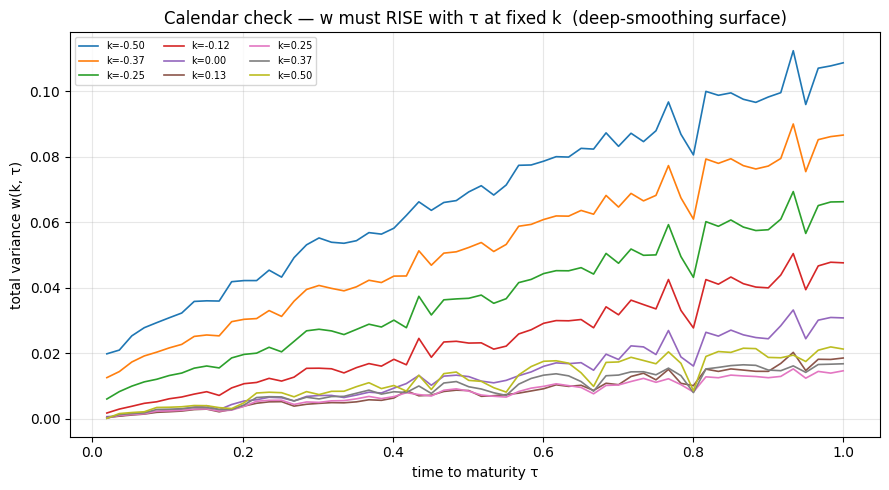

calendar slope violations (dw/dτ < 0) across the fixed-k lines: 187


In [19]:
# ---- CELL R : reproduce paper Figure 1 + calendar arbitrage ----------------
import numpy as np, matplotlib.pyplot as plt

# maturities present in the data, and a k-grid
taus = np.sort(df["tau"].unique())
kg   = np.linspace(df["log_moneyness"].min(), df["log_moneyness"].max(), 80)
cmap = plt.cm.viridis

# ---------- ROW 1: total variance — Data | Prior | Prior x NN ----------
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for j, (title, fn) in enumerate([("Data", None),
                                 ("Prior", prior_w),
                                 ("Prior x NN", deep_w)]):
    for i, tau in enumerate(taus):
        c = cmap(i / max(1, len(taus)-1))
        if title == "Data":
            d = df[np.isclose(df["tau"], tau)].sort_values("log_moneyness")
            ax[j].plot(d["log_moneyness"], d["total_var"], color=c, lw=1, marker=".", ms=3)
        else:
            ax[j].plot(kg, fn(kg, np.full_like(kg, tau)), color=c, lw=1.2)
    ax[j].set_title(title); ax[j].set_xlabel("log-moneyness")
ax[0].set_ylabel("total variance  w = σ²τ")
fig.suptitle(f"{TICKER} — total variance: data vs prior vs prior×NN (colored by maturity)")
plt.tight_layout(); plt.show()

# ---------- ROW 2: implied vol, a few maturity panels ----------
pick = taus[[0, len(taus)//3, 2*len(taus)//3, -1]]      # 4 representative maturities
fig, ax = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
for j, tau in enumerate(pick):
    d = df[np.isclose(df["tau"], tau)].sort_values("log_moneyness")
    ax[j].plot(d["log_moneyness"], d["iv"], "o", ms=4, color="#c0392b", label="data")
    ax[j].plot(kg, np.sqrt(np.maximum(prior_w(kg, np.full_like(kg, tau)),1e-12)/tau),
               color="#27ae60", lw=2, label="prior")
    ax[j].plot(kg, np.sqrt(np.maximum(deep_w(kg, np.full_like(kg, tau)),1e-12)/tau),
               color="#7f77dd", lw=2, label="prior×NN")
    ax[j].set_title(f"τ ≈ {tau:.2f} ({int(round(tau*365))}d)"); ax[j].set_xlabel("log-moneyness")
ax[0].set_ylabel("implied vol"); ax[0].legend(fontsize=8)
fig.suptitle(f"{TICKER} — implied vol fit per maturity"); plt.tight_layout(); plt.show()

# ---------- ROW 3: extended grid (extrapolation behavior) ----------
k_ext = np.linspace(-2, 2, 120)                          # far beyond the quoted range
tau_ext = np.linspace(taus.min(), taus.max()*1.3, 40)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for j, (title, fn) in enumerate([("Prior", lambda k,t: prior_w(k,t)),
                                 ("NN correction only", lambda k,t: deep_w(k,t)/np.maximum(prior_w(k,t),1e-12)),
                                 ("Prior x NN", deep_w)]):
    for i, tau in enumerate(tau_ext):
        c = cmap(i/len(tau_ext))
        ax[j].plot(k_ext, fn(k_ext, np.full_like(k_ext, tau)), color=c, lw=0.7)
    ax[j].set_title(title); ax[j].set_xlabel("log-moneyness")
ax[0].set_ylabel("total variance"); fig.suptitle(f"{TICKER} — extended grid (extrapolation)")
plt.tight_layout(); plt.show()

# ---------- CALENDAR ARBITRAGE: total variance must be non-decreasing in τ ----------
tau_fine = np.linspace(taus.min(), taus.max(), 60)
k_fixed  = np.linspace(df["log_moneyness"].min(), df["log_moneyness"].max(), 9)
fig, ax = plt.subplots(figsize=(9, 5))
violations = 0
for k0 in k_fixed:
    w_line = deep_w(np.full_like(tau_fine, k0), tau_fine)
    dwdt = np.diff(w_line)
    violations += int((dwdt < 0).sum())
    ax.plot(tau_fine, w_line, lw=1.2, label=f"k={k0:.2f}")
ax.set_xlabel("time to maturity τ"); ax.set_ylabel("total variance w(k, τ)")
ax.set_title(f"Calendar check — w must RISE with τ at fixed k  (deep-smoothing surface)")
ax.legend(fontsize=7, ncol=3); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"calendar slope violations (dw/dτ < 0) across the fixed-k lines: {violations}")

In [20]:
svi_surf = {}
for tau_v, g in df.groupby(df["tau"].round(6)):
    p = fit_slice(g["log_moneyness"].values, (g["iv"].values ** 2) * float(tau_v))
    if p is not None:
        svi_surf[float(tau_v)] = p
svi_taus = np.array(sorted(svi_surf)); svi_pars = np.array([svi_surf[t] for t in svi_taus])

def svi_surface_w(k, t):
    k = np.asarray(k, float); t = np.asarray(t, float)
    a   = np.interp(t, svi_taus, svi_pars[:,0]); b   = np.interp(t, svi_taus, svi_pars[:,1])
    rho = np.interp(t, svi_taus, svi_pars[:,2]); m   = np.interp(t, svi_taus, svi_pars[:,3])
    sig = np.interp(t, svi_taus, svi_pars[:,4])
    return np.maximum(a + b*(rho*(k-m) + np.sqrt((k-m)**2 + sig**2)), 1e-8)

# the three surfaces we will hedge with
SURFACES = {"SVI": svi_surface_w, "Vanilla NN": vanilla_w, "Deep Smoothing": deep_w}


# --- Step 1: Black-Scholes building blocks (rate = 0 for simplicity) ----------
def implied_vol(w_fn, k, tau):
    """total variance -> implied vol.  sigma = sqrt(w / tau)."""
    tau = np.maximum(np.asarray(tau, float), 1e-12)
    return np.sqrt(np.clip(w_fn(k, tau), 1e-12, None) / tau)

def bs_call_price(S, K, tau, sigma):
    """Black-Scholes call price, rate 0. Vectorized over S/tau/sigma arrays."""
    S = np.asarray(S, float); tau = np.maximum(np.asarray(tau, float), 1e-12)
    sigma = np.maximum(np.asarray(sigma, float), 1e-8)
    d1 = (np.log(S/K) + 0.5*sigma**2*tau) / (sigma*np.sqrt(tau))
    d2 = d1 - sigma*np.sqrt(tau)
    return S*norm.cdf(d1) - K*norm.cdf(d2)

def bs_vega(S, K, tau, sigma):
    """dPrice/dSigma — how much the option price moves per unit of vol."""
    S = np.asarray(S, float); tau = np.maximum(np.asarray(tau, float), 1e-12)
    sigma = np.maximum(np.asarray(sigma, float), 1e-8)
    d1 = (np.log(S/K) + 0.5*sigma**2*tau) / (sigma*np.sqrt(tau))
    return S*norm.pdf(d1)*np.sqrt(tau)


# --- Step 2: the SMILE-AWARE delta (the whole point) --------------------------
# Plain BS delta = N(d1) treats vol as fixed. But on a real surface, when the
# stock moves you slide along the smile to a DIFFERENT implied vol. The extra
# term captures that:   delta = N(d1)  +  vega * dSigma/dS
# with  dSigma/dS = dSigma/dk * dk/dS  and  k = log(K/S)  =>  dk/dS = -1/S.
# dSigma/dk (the SMILE SLOPE) is where the methods differ — a wiggly surface has
# a noisy slope and therefore a noisy delta.
def smile_delta(w_fn, S, K, tau, eps=1e-3):
    S = np.asarray(S, float); tau = np.asarray(tau, float)
    k = np.log(K / S)
    sigma = implied_vol(w_fn, k, tau)
    d1 = (np.log(S/K) + 0.5*sigma**2*np.maximum(tau,1e-12)) / (sigma*np.sqrt(np.maximum(tau,1e-12)))
    delta_bs = norm.cdf(d1)
    # smile slope dSigma/dk via a tiny finite difference in moneyness
    dsig_dk = (implied_vol(w_fn, k+eps, tau) - implied_vol(w_fn, k-eps, tau)) / (2*eps)
    dsig_dS = dsig_dk * (-1.0 / S)
    return delta_bs + bs_vega(S, K, tau, sigma) * dsig_dS


# --- Step 3: simulate stock paths (same for every method!) --------------------
S0      = 100.0                 # arbitrary spot; surface only depends on k=log(K/S)
T       = 30/365                # 30-day option
N_STEPS = 30                    # rebalance daily
M_PATHS = 3000                  # number of simulated paths
# simulate at a realistic vol: the ATM implied vol at this maturity
SIGMA_SIM = float(implied_vol(svi_surface_w, np.array([0.0]), np.array([T]))[0])

rng = np.random.default_rng(0)  # fixed seed => identical paths for all methods
dt  = T / N_STEPS
z   = rng.standard_normal((M_PATHS, N_STEPS))
incr = (-0.5*SIGMA_SIM**2*dt) + SIGMA_SIM*np.sqrt(dt)*z
paths = S0 * np.exp(np.concatenate([np.zeros((M_PATHS,1)), np.cumsum(incr, axis=1)], axis=1))
print(f"simulated {M_PATHS} paths, sigma_sim = {SIGMA_SIM:.3f}, {N_STEPS} daily steps")


# --- Step 4: the delta-hedge engine ------------------------------------------
# We SELL one call (receive its price), then dynamically hold `delta` shares to
# offset it. P&L at expiry = premium + trading gains - payoff. Perfectly hedged
# => P&L ~ 0; a bad delta => P&L spreads out. We do this VECTORIZED over paths
# (one surface query per time step, not per path) so it's fast.
def delta_hedge_pnl(w_fn, K):
    S = paths
    M = S.shape[0]
    tau0 = np.full(M, T)
    # premium received: price the call on this surface at t=0
    sig0 = implied_vol(w_fn, np.log(K/S[:,0]), tau0)
    cash = bs_call_price(S[:,0], K, T, sig0)
    # buy initial hedge
    prev = smile_delta(w_fn, S[:,0], K, tau0)
    cash -= prev * S[:,0]
    # rebalance each day
    for i in range(1, N_STEPS+1):
        tau_i = T - i*dt
        if tau_i <= 1e-9:
            delta = np.zeros(M)                       # at expiry, unwind hedge
        else:
            delta = smile_delta(w_fn, S[:,i], K, np.full(M, tau_i))
        cash -= (delta - prev) * S[:,i]               # cost of adjusting shares
        prev = delta
    # settle: sell remaining shares, pay the payoff
    cash += prev * S[:,-1] - np.maximum(S[:,-1] - K, 0.0)
    return cash                                        # array of P&L, one per path


# --- Step 5: run for a few strikes and collect P&L ----------------------------
# Differences show up in the WINGS (OTM), not ATM — so test a few moneyness levels.
MONEYNESS = [0.95, 1.00, 1.05]                          # K / S0
pnl_results = {}                                        # (method, moneyness) -> pnl array
for name, wf in SURFACES.items():
    for mny in MONEYNESS:
        pnl_results[(name, mny)] = delta_hedge_pnl(wf, K=S0*mny)

# summary table: hedging-error std and worst 5% loss, per method (pooled strikes)
print("\nDelta-hedging P&L (lower std = better hedge; left tail = worst losses)")
print(f"{'method':16s} {'P&L std':>10s} {'mean':>9s} {'5% worst':>10s}")
hedge_stats = {}
for name in SURFACES:
    pooled = np.concatenate([pnl_results[(name, m)] for m in MONEYNESS])
    hedge_stats[name] = {"pnl_std": float(pooled.std()),
                         "pnl_mean": float(pooled.mean()),
                         "pnl_p05": float(np.percentile(pooled, 5))}
    s = hedge_stats[name]
    print(f"{name:16s} {s['pnl_std']:10.4f} {s['pnl_mean']:9.4f} {s['pnl_p05']:10.4f}")


# --- Step 6: plot the P&L distributions for the OTM strike (where it matters) --
mny_show = 1.05
plt.figure(figsize=(9,5))
for name, color in zip(SURFACES, ["#2ca02c","#1f77b4","#d62728"]):
    plt.hist(pnl_results[(name, mny_show)], bins=60, alpha=0.5, label=name, color=color)
plt.axvline(0, color="k", lw=1)
plt.xlabel("hedging P&L  (per option, $)"); plt.ylabel("paths")
plt.title(f"{TICKER} — delta-hedging P&L, {int(mny_show*100)}% strike  (tighter = better)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


# =============================================================================
# ---- CELL H2 : collect ALL results and save them ----------------------------
# Pulls together the three axes — fit (RMSE), validity (butterfly + calendar),
# and consequences (hedging P&L) — into one table and writes it to Drive, so you
# don't recompute and so the team has the numbers for slides.
# =============================================================================
import json, os

# (a) arbitrage counts for ALL three surfaces, same grid, same check
kg = np.linspace(df["log_moneyness"].min(), df["log_moneyness"].max(), 60)
tg = np.linspace(df["tau"].min(), df["tau"].max(), 30)
KKr, TTr = np.meshgrid(kg, tg); KKr, TTr = KKr.ravel(), TTr.ravel()
arb = {}
for name, wf in SURFACES.items():
    b, c = count_violations_grid(wf, KKr, TTr)         # (butterfly, calendar)
    arb[name] = {"butterfly": b, "calendar": c}

# (b) assemble one summary row per method
rows = []
for name in SURFACES:
    rows.append({
        "method":          name,
        "holdout_rmse":    round(results.get(name, np.nan), 6),
        "butterfly_viol":  arb[name]["butterfly"],
        "calendar_viol":   arb[name]["calendar"],
        "hedge_pnl_std":   round(hedge_stats[name]["pnl_std"], 6),
        "hedge_pnl_mean":  round(hedge_stats[name]["pnl_mean"], 6),
        "hedge_pnl_p05":   round(hedge_stats[name]["pnl_p05"], 6),
    })
summary = pd.DataFrame(rows)
print("\n================ FULL RESULTS SUMMARY ================")
print(summary.to_string(index=False))

# (c) save: a tidy CSV for slides, a JSON for completeness, raw P&L as parquet
os.makedirs(DRIVE, exist_ok=True)
summary.to_csv(f"{DRIVE}/results_summary_{TICKER}.csv", index=False)

raw_pnl = pd.DataFrame({f"{n}_{m}": pnl_results[(n, m)]
                        for n in SURFACES for m in MONEYNESS})
raw_pnl.to_parquet(f"{DRIVE}/hedge_pnl_{TICKER}.parquet")

json.dump({"ticker": TICKER, "sigma_sim": SIGMA_SIM, "T": T,
           "arbitrage": arb, "hedge": hedge_stats,
           "holdout_rmse": {k: results.get(k) for k in SURFACES}},
          open(f"{DRIVE}/results_{TICKER}.json", "w"), indent=2)

print(f"\nsaved:\n  {DRIVE}/results_summary_{TICKER}.csv"
      f"\n  {DRIVE}/hedge_pnl_{TICKER}.parquet"
      f"\n  {DRIVE}/results_{TICKER}.json")

simulated 3000 paths, sigma_sim = 0.149, 30 daily steps


NameError: name 'norm' is not defined